In [3]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)


# Dados


df = pd.read_csv("../ubernymaio14_tratado.csv")

X = df[['Lat', 'Lon', 'Hour', 'Day']]

# ELBOW


inercia = []

for k in range(2, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X)

    inercia.append(km.inertia_)

print("Inércias:")
for k, i in zip(range(2,11), inercia):
    print(f"K={k}: {i:.2f}")

Inércias:
K=2: 117047.82
K=3: 43592.24
K=4: 24764.74
K=5: 15813.82
K=6: 11766.22
K=7: 8421.57
K=8: 5885.92
K=9: 5208.24
K=10: 4482.72


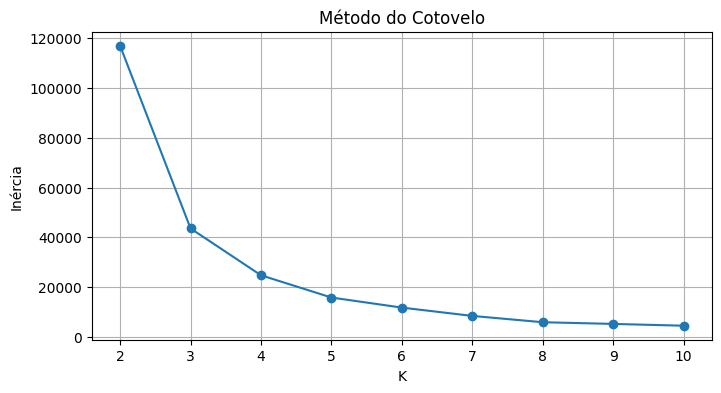

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(range(2,11), inercia, marker='o')
plt.xlabel("K")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo")
plt.grid()
plt.show()

In [6]:
K = 4


resultados = []

# =========================
# KMEANS
# =========================

kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X)

resultados.append([
    "KMeans",
    silhouette_score(X, labels),
    davies_bouldin_score(X, labels),
    calinski_harabasz_score(X, labels)
])


# AGGLOMERATIVE COMPLETE


agg = AgglomerativeClustering(
    n_clusters=K,
    linkage='complete'
)

labels = agg.fit_predict(X)

resultados.append([
    "Agglomerative Complete",
    silhouette_score(X, labels),
    davies_bouldin_score(X, labels),
    calinski_harabasz_score(X, labels)
])


# DBSCAN


dbscan = DBSCAN(
    eps=0.10,
    min_samples=10
)

labels = dbscan.fit_predict(X)

# DBSCAN pode gerar ruido (-1)
mask = labels != -1

resultados.append([
    "DBSCAN",
    silhouette_score(X[mask], labels[mask]),
    davies_bouldin_score(X[mask], labels[mask]),
    calinski_harabasz_score(X[mask], labels[mask])
])

resultado_df = pd.DataFrame(
    resultados,
    columns=[
        "Algoritmo",
        "Silhouette",
        "Davies-Bouldin",
        "Calinski-Harabasz"
    ]
)

print(resultado_df)

                Algoritmo  Silhouette  Davies-Bouldin  Calinski-Harabasz
0                  KMeans    0.589517        0.522723      102133.092584
1  Agglomerative Complete    0.538282        0.523932       72628.379161
2                  DBSCAN    0.739991        0.405991      484335.008271


In [4]:
seeds = [0,1,2,42,100]

rotulos = []

for seed in seeds:

    km = KMeans(
        n_clusters=K,
        random_state=seed,
        n_init=10
    )

    labels = km.fit_predict(X)

    rotulos.append(labels)

print("ARI entre execuções:\n")

for i in range(len(seeds)):
    for j in range(i+1, len(seeds)):

        ari = adjusted_rand_score(
            rotulos[i],
            rotulos[j]
        )

        print(
            f"{seeds[i]} x {seeds[j]} -> {ari:.4f}"
        )

ARI entre execuções:

0 x 1 -> 1.0000
0 x 2 -> 1.0000
0 x 42 -> 1.0000
0 x 100 -> 1.0000
1 x 2 -> 1.0000
1 x 42 -> 1.0000
1 x 100 -> 1.0000
2 x 42 -> 1.0000
2 x 100 -> 1.0000
42 x 100 -> 1.0000
